## Crow Search Algorithm : Medical Domain
### Trinome: AMRANI_Hasna & IDHAMOU_Younes & ROUI_Ilham
### Module: Data Mining
#### Optimisation des hyperparamètres de quelques modèles de machine learning pour optimiser la prédiction de diabettes

# -------------------------------------------------------------------------------------------------------- 

### Importer les bibliothèques nécessaires 

In [1]:
import warnings #pour gérer les exceptions
warnings.filterwarnings('ignore')
import numpy as np #destinée à manipuler des matrices ou tableaux multidimensionnels ainsi que des fonctions mathématiques opérant sur ces tableaux.
import matplotlib.pyplot as plt # fournit une façon implicite de tracer les graphiques. Il ouvre également les chiffres sur votre écran, et agit comme le gestionnaire graphique.
import seaborn as sns # fournit une interface de haut niveau pour dessiner des graphiques statistiques attrayants
import plotly.express as px #fonctionne avec des données orientées colonnes, matricielles ou géographiques. Plotly Express est l’interface de haut niveau facile à utiliser
import pandas as pd #permettant la manipulation et l'analyse des données. 
from sklearn.preprocessing import StandardScaler #Normaliser les caractéristiques en supprimant la moyenne et en ajustant la variance unitaire.
from sklearn.model_selection import train_test_split # pour déviser le jeu de données en training et testing 
from sklearn.neighbors import KNeighborsClassifier #pour utiliser KNN
from sklearn.metrics import accuracy_score # pour calculer l'accuracy
from sklearn.metrics import recall_score # pour calculer recall_score
from sklearn.utils import resample #pour équilibrer | blancer le jeu de données 
from sklearn.linear_model import LogisticRegression # pour utiliser logistic regression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # permet de visualiser la matrice de confusion
from math import * # pour les calcules mathématiques
import math # pour les calcules mathématiques
import random # pour choisir une valeur aléatoirement
import os #permet d’utiliser les fonctionnalités dépendantes du système d’exploitation. 
%matplotlib inline
sns.set_style('darkgrid')

### Lecture du jeu de données diabetes

In [2]:
df = pd.read_csv('C:/Users/HP/Documents/SDAD_S3/DM/crow/diabetes.csv')
df.head() # afficher les premières liges

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
#Dimension du jeu de données
print("Dimension Diabetes est : ==> ",df.shape)

Dimension Diabetes est : ==>  (768, 9)


### Nettoyage du jeu de données

In [4]:
# Savoir si on a les valeurs null
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
# quelques informations statistique sur le jeu de données
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [6]:
#vérifier si on a des valeurs nulls dans chaque variable
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Il n'y a pas de valeurs manquantes

In [7]:
# la matrice de corrélation par rapport à la variable cible Outcome 
corr_matrix = df.corr()
corr_matrix["Outcome"].sort_values(ascending=False)

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64

On obtient corrélations faible ne sont pas proche de 1. La plus élevée c'est celle du Glucose 0.46 qui représente une corrélation 
faiblement positive avec target

##### exist-ils Les valeurs aberrantes? 

<AxesSubplot:xlabel='DiabetesPedigreeFunction'>

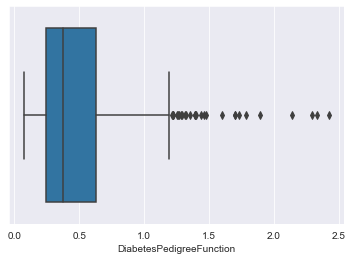

In [8]:
# Boite à moustache Pour la variable DiabetesPedigreeFunction
sns.boxplot(data=df, x="DiabetesPedigreeFunction")

On a des valeurs aberrantes pour cette variable. Remarquons que tous les valeurs >~ 1.2 représentent valeurs aberrantes

<AxesSubplot:xlabel='Insulin'>

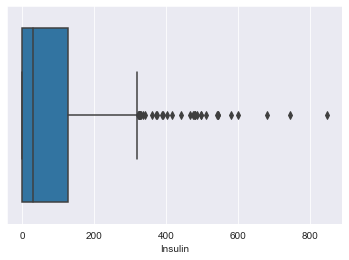

In [9]:
# Boite à moustache Pour la variable Insulin
sns.boxplot(data=df, x="Insulin")

On a des valeurs aberrantes pour cette variable. Remarquons que tous les valeurs >~ 300 représentent valeurs aberrantes

<AxesSubplot:xlabel='Glucose'>

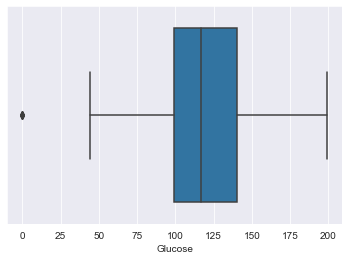

In [10]:
# Boite à moustache Pour la variable Glucose
sns.boxplot(data=df, x="Glucose")

Les valeurs aberrantes pour cette variable c'est 0. On peut éxpliquer ça par : la personne ne fait pas les analyses de Glucose.

<AxesSubplot:xlabel='Pregnancies'>

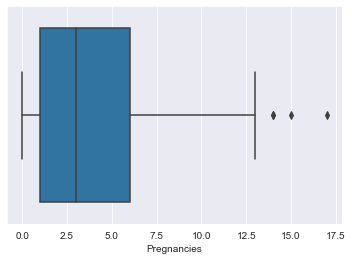

In [11]:
# Boite à moustache Pour la variable Pregnancies
sns.boxplot(data=df, x="Pregnancies")

Pour cette variables on a 3 valeurs aberrantes sont tous > 12.5

<AxesSubplot:xlabel='BloodPressure'>

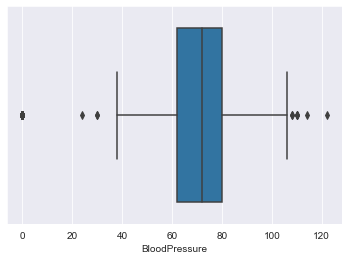

In [12]:
# Boite à moustache Pour la variable BloodPressure
sns.boxplot(data=df, x="BloodPressure")

4 valeurs aberrantes : les valeurs >105 
3 valeurs aberrantes :les valeurs qui sont < 39

<AxesSubplot:xlabel='BMI'>

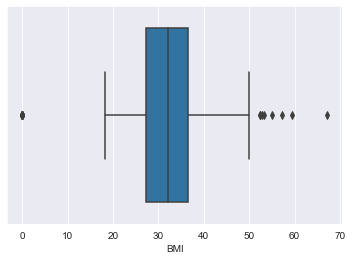

In [13]:
# Boite à moustache Pour la variable BMI
sns.boxplot(data=df, x="BMI")

6 valeurs aberrantes > 50 
1 valeurs aberrante=0

#### En remplace ces valeurs aberrantes par la moyenne (de chaque variable)

In [14]:
#On va remplacer les valeurs egal 0 par la moyenne de la variable
for i in df[df['BloodPressure']==0]['BloodPressure'].index:
    df['BloodPressure'][i]=df['BloodPressure'].mean()
for i in df[df['SkinThickness']==0]['SkinThickness'].index:
    df['SkinThickness'][i]=df['SkinThickness'].mean()
for i in df[df['Insulin']==0]['Insulin'].index:
    df['Insulin'][i]=df['Insulin'].mean()
for i in df[df['BMI']==0]['BMI'].index:
    df['BMI'][i]=df['BMI'].mean()


In [15]:
df.iloc[7]

Pregnancies                  10.000
Glucose                     115.000
BloodPressure                69.000
SkinThickness                20.000
Insulin                      80.000
BMI                          35.300
DiabetesPedigreeFunction      0.134
Age                          29.000
Outcome                       0.000
Name: 7, dtype: float64

<AxesSubplot:xlabel='SkinThickness'>

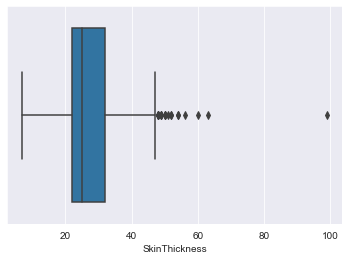

In [16]:
sns.boxplot(data=df, x="SkinThickness")

In [17]:
# On remplace les valeurs aberrantes de la variable Glucose par la moyenne de cet dérnière
for i in df[df['Glucose']<2]['Glucose'].index:
    df['Glucose'][i]=df['Glucose'].mean()
df.describe() # on affiche les statistiques des variables

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.00000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.68099,72.304688,27.419271,129.519531,32.453800,0.471876,33.240885,0.348958
std,3.369578,30.43605,12.106799,9.255676,89.684233,6.875237,0.331329,11.760232,0.476951
min,0.000000,44.00000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.75000,64.000000,22.000000,87.000000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.00000,72.000000,25.000000,106.000000,32.264327,0.372500,29.000000,0.000000
75%,6.000000,140.25000,80.000000,32.000000,129.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.00000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.128826       0.192067       0.032604   
Glucose                      0.128826  1.000000       0.243698       0.151198   
BloodPressure                0.192067  0.243698       1.000000       0.158467   
SkinThickness                0.032604  0.151198       0.158467       1.000000   
Insulin                      0.047355  0.427859       0.062402       0.305533   
BMI                          0.000659  0.225460       0.288808       0.546514   
DiabetesPedigreeFunction    -0.043242  0.090316       0.011024       0.090857   
Age                          0.607216  0.281470       0.368962       0.107890   
Outcome                      0.198689  0.481661       0.169334       0.182807   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies               0.047355  0.000659                 -0.043242   
Glucose                   0.427859  0.225

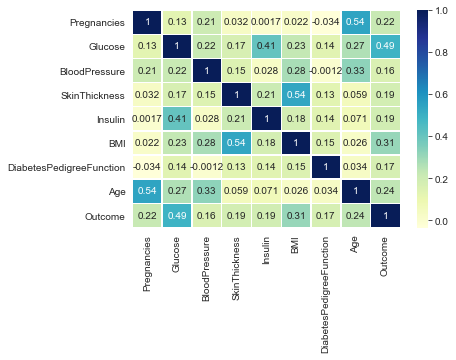

In [18]:
# Matrice de corrélation
correlation = df.corr(method='pearson')
sns.heatmap(correlation, 
            xticklabels=correlation.columns,
            yticklabels=correlation.columns,
            cmap="YlGnBu",
            annot=True,
            linewidth=0.5)
spearman_correlation=df.corr(method='spearman')
print(spearman_correlation)
kendall_correlation=df.corr(method='kendall')
print(kendall_correlation)

### Visualisation 

*Density des variables

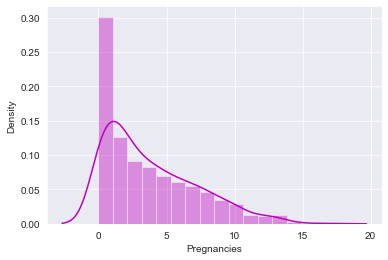

In [19]:
plot00=sns.distplot(df['Pregnancies'],color='m')

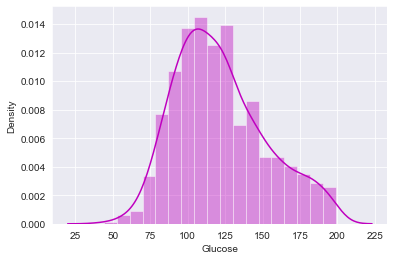

In [20]:
plot00=sns.distplot(df['Glucose'],color='m')

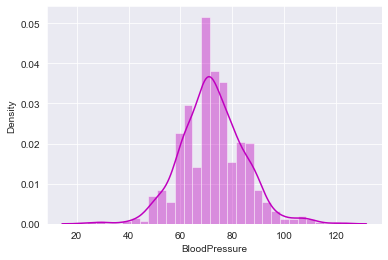

In [21]:
plot00=sns.distplot(df['BloodPressure'],color='m')

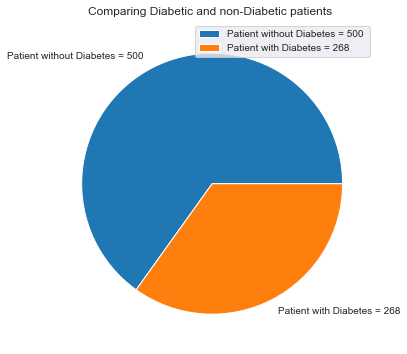

In [22]:
# dispertion des données : nbr de personnes avec et sans diabète
diabetes_count = np.array(df['Outcome'].value_counts(sort=True))
labels = ['Patient without Diabetes = 500 ', 'Patient with Diabetes = 268']
plt.figure(figsize=(8,6))
plt.pie(diabetes_count, labels=labels)
plt.legend()
plt.title('Comparing Diabetic and non-Diabetic patients ')
plt.show()

D'après ce graphe on peut dire que notre jeu de données n'est pas équlibrés (nbr with diabetes & without diabetes)

##### Balance of data : équilibrer le jeu de données

In [23]:
#classe minoritaire et majoritaire séparées
class_1=df[df['Outcome']==0]
class_2=df[df['Outcome']==1]
#échantillon mineur suréchantillonné
class_2_upsampled=resample(class_2,replace=True,n_samples=len(class_1),random_state=27)
#combiner la majorité et l’échantillon mineur non échantillonné
upsampled=pd.concat([class_1,class_2_upsampled])
upsampled['Outcome'].value_counts()
data=upsampled


<AxesSubplot:xlabel='Outcome', ylabel='count'>

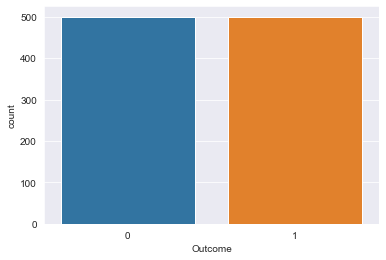

In [24]:
#  La dispertion des personnes avec et sans diabète après balancement du jeu de données
sns.countplot("Outcome",data=data)

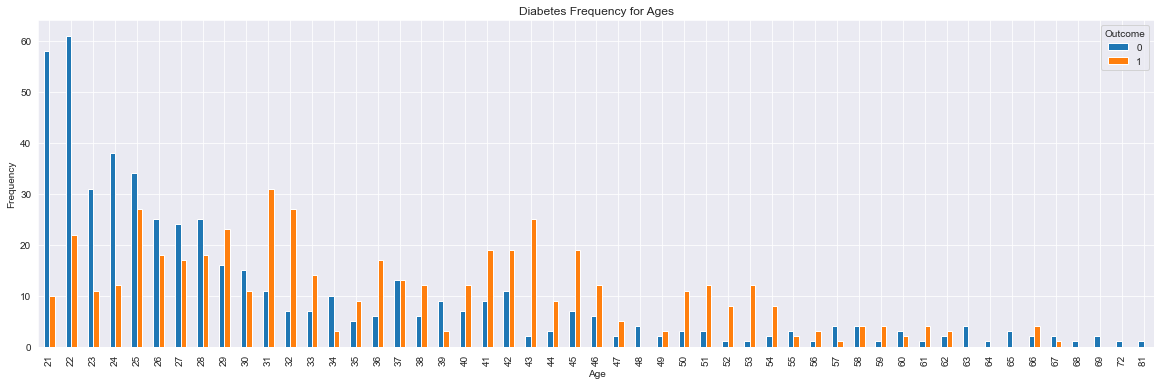

In [25]:
#fréquence déabète par age
pd.crosstab(data.Age,data.Outcome).plot(kind="bar",figsize=(20,6))
plt.title('Diabetes Frequency for Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

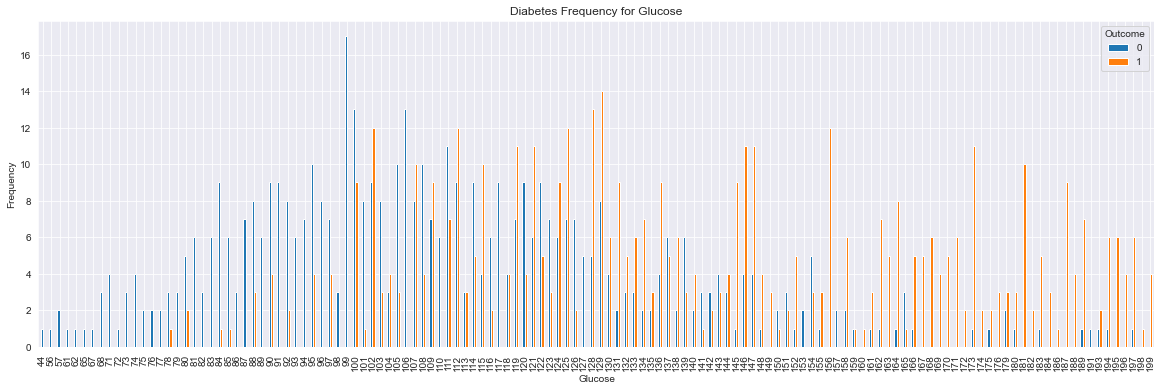

In [26]:
#fréauence diabete par Glucose
pd.crosstab(data.Glucose,data.Outcome).plot(kind="bar",figsize=(20,6))
plt.title('Diabetes Frequency for Glucose')
plt.xlabel('Glucose')
plt.ylabel('Frequency')
plt.show()

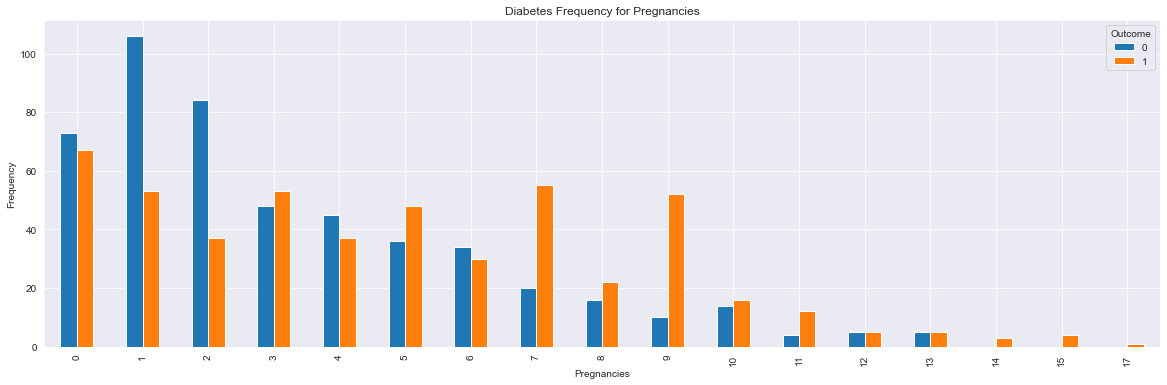

In [27]:
#fréquence diabète par pregnancies
pd.crosstab(data.Pregnancies,data.Outcome).plot(kind="bar",figsize=(20,6))
plt.title('Diabetes Frequency for Pregnancies')
plt.xlabel('Pregnancies')
plt.ylabel('Frequency')
plt.show()

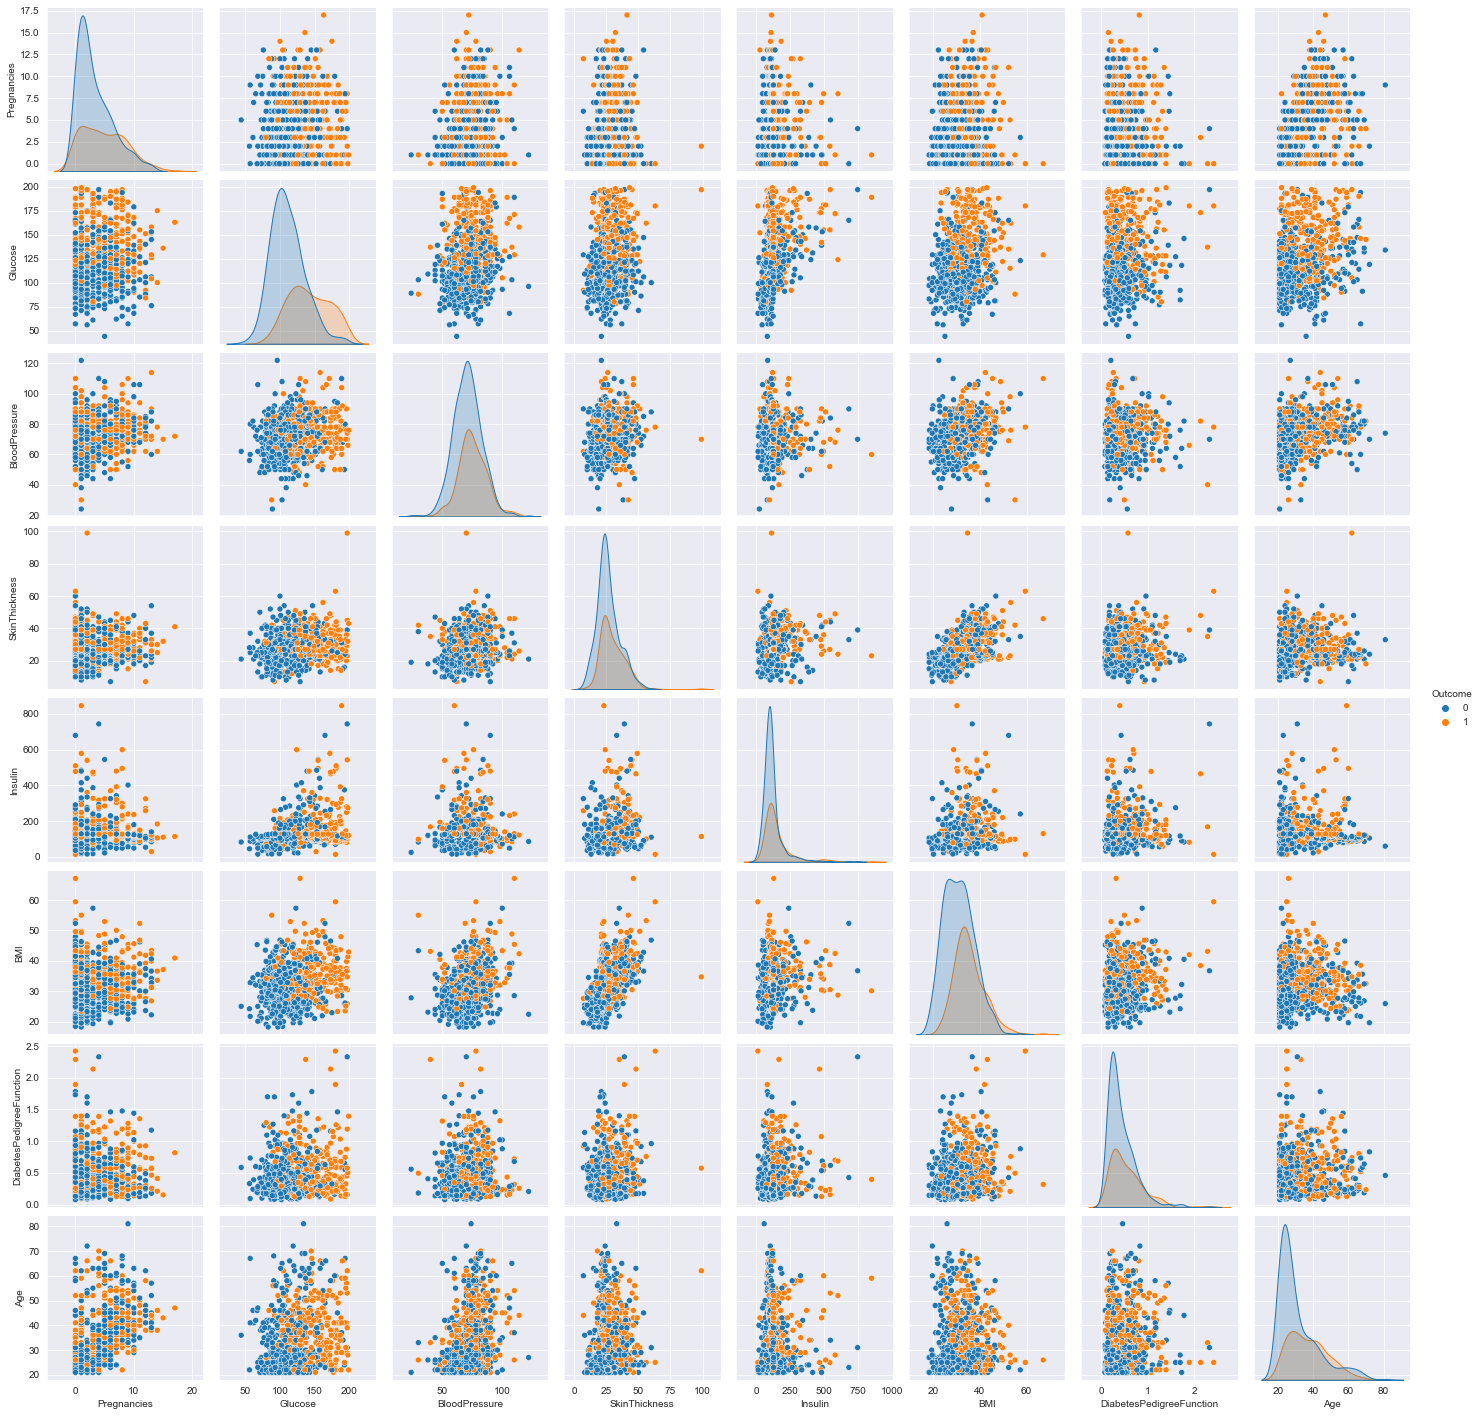

In [28]:
#dispertion du jeu de données
sns.pairplot(df, hue = 'Outcome')

### Scale and Split of data

In [29]:
scale = StandardScaler()

In [30]:

x = df.drop(['Outcome'], axis=1)
y = df['Outcome'].astype(float)
x=scale.fit_transform(x)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.20, random_state = 0)

## KNN

#### Sans CSA

In [31]:

classifier= KNeighborsClassifier(n_neighbors=5, p=2, metric='minkowski')

#Fit the model for the data

classifier.fit(x_train, y_train)

#Make the prediction
y_pred = classifier.predict(x_test)
accuracy_KNN_without = accuracy_score(y_test,y_pred)*100

In [32]:
accuracy_KNN_without

78.57142857142857

#### Avec CSA : en cherche à optimiser n_neighbors & p

In [33]:
#CSA
def fitness(variables_values = []):
    classifier= KNeighborsClassifier(n_neighbors=math.ceil(variables_values[0]), p=math.ceil(variables_values[1]), metric='minkowski')
    classifier.fit(x_train, y_train)
    y_pred = classifier.predict(x_test)
    accuracy = accuracy_score(y_test,y_pred)*100
    return accuracy
def initial_population(population_size = 30, min_values = [5,1], max_values = [120,3], target_function = fitness):
    population = np.zeros((population_size, len(min_values) + 1))
    for i in range(0, population_size):
        for j in range(0, len(min_values)):
            population[i,j] = random.uniform(min_values[j], max_values[j]) 
        population[i,-1] = target_function(population[i, 0:population.shape[1]-1])
    return population
def update_position(population, ap, fL, min_values = [5,1], max_values = [120,3], target_function = fitness):
    for i in range(0, population.shape[0]):
        idx  = [i for i in range(0, population.shape[0])]
        idx.remove(i)
        idx  = random.choice(idx)
        rand = int.from_bytes(os.urandom(8), byteorder = 'big') / ((1 << 64) - 1)
        for j in range(0, len(min_values)):
            if (rand >= ap):
                rand_i           = int.from_bytes(os.urandom(8), byteorder = 'big') / ((1 << 64) - 1)
                population[i, j] = np.clip(population[i, j] + rand_i*fL*( population[idx, j] - population[i, j]), min_values[j], max_values[j])
            else:
                population[i,j] = random.uniform(min_values[j], max_values[j]) 
        population[i,-1] = target_function(population[i, 0:population.shape[1]-1])
    return population
def crow_search_algorithm(population_size = 30, ap = 0.02, fL = 2, min_values = [5,1], max_values = [120,3], iterations = 50, target_function = fitness):
    rem=[]
    count      = 0
    population = initial_population(population_size, min_values, max_values, target_function)
    best_ind   = np.copy(population[population[:,-1].argsort()][ 0,:])
    while (count <= iterations):  
        population = update_position(population, ap, fL, min_values, max_values, target_function)
        for i in range(0,population_size):
            value      = np.copy(population[i,:])
            rem.append(value)
            if(best_ind[-1] < value[-1]):
                best_ind = value
        count = count + 1 
    best_ind[1]=int(ceil(best_ind[1]))
    return best_ind,rem

In [34]:
resultat_KNN=crow_search_algorithm()
resultat_KNN
# différents positions visités par CSA : [n_neighbors , p, accuracy]

(array([31.2656711 ,  1.        , 83.76623377]),
 [array([37.87150311,  1.65564461, 80.51948052]),
  array([68.60405494,  1.67697974, 81.16883117]),
  array([ 5.        ,  1.77639804, 78.57142857]),
  array([23.28958765,  1.92015235, 82.46753247]),
  array([26.78287344,  1.90805135, 83.11688312]),
  array([ 9.36220682,  1.32017495, 78.57142857]),
  array([73.99387766,  1.56142933, 79.22077922]),
  array([13.98463172,  2.18887575, 81.16883117]),
  array([105.0098008 ,   1.13150813,  79.87012987]),
  array([47.31677158,  1.        , 80.51948052]),
  array([58.92893929,  1.42510725, 81.81818182]),
  array([52.87876512,  2.71283402, 79.87012987]),
  array([ 5.        ,  1.4849234 , 78.57142857]),
  array([114.21787908,   1.        ,  78.57142857]),
  array([56.65159151,  1.5163826 , 81.16883117]),
  array([ 5.        ,  1.47054118, 78.57142857]),
  array([56.44471171,  1.34449746, 81.16883117]),
  array([98.30159711,  1.95532254, 79.87012987]),
  array([84.42178115,  1.15131091, 79.8701298

In [35]:
resultat_KNN[0]#best position

array([31.2656711 ,  1.        , 83.76623377])

In [36]:
accuracy_KNN_withCSA=resultat_KNN[0][2]
accuracy_KNN_withCSA#accuracy si on utilise CSA

83.76623376623377

In [37]:
# les positions visités par CSA en 3d : n_neighbors, p, accuracy 
ds=pd.DataFrame(data=resultat_KNN[1])
ds=ds.sort_values(by=[0,1])
ds=ds.drop_duplicates()
fig = px.scatter_3d(ds, x = 0, y = 1, z = 2)
fig.show()

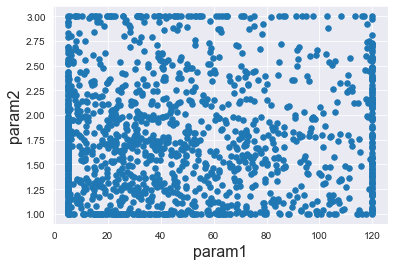

In [38]:
# en 2D : n_neighbors et p
plt.scatter(ds[0], ds[1],s=30)
plt.xlabel('param1', fontsize=16)
plt.ylabel('param2', fontsize=16)
plt.show()

## RandomForest

#### Sans CSA

In [39]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(max_depth=10,n_estimators =5)
classifier.fit(x_train, y_train)
y_pred_RF_sans = classifier.predict(x_test)
accuracy_RF_without = accuracy_score(y_test,y_pred_RF_sans)*100
print("accuracy=",accuracy_RF_without)
print("recall=",recall_score(y_test,y_pred))


accuracy= 76.62337662337663
recall= 0.6170212765957447


#### Avec CSA pour optimiser: max_depth,n_estimators

In [40]:
#csa
def fitness(variables_values = [3,8]):
    classifier = RandomForestClassifier(max_depth=math.ceil(variables_values[0]),n_estimators =math.ceil(variables_values[1]))
    classifier.fit(x_train, y_train)
    y_pred_RF_avec= classifier.predict(x_test)
    accuracy = accuracy_score(y_test,y_pred_RF_avec)*100
    return accuracy
def initial_population(population_size = 5, min_values = [2,2], max_values = [100,10], target_function = fitness):
    population = np.zeros((population_size, len(min_values) + 1))
    for i in range(0, population_size):
        for j in range(0, len(min_values)):
            population[i,j] = random.uniform(min_values[j], max_values[j])
        population[i,-1] = target_function(population[i, 0:population.shape[1]-1])
    return population
def update_position(population, ap, fL, min_values = [2,2], max_values = [100,10], target_function = fitness):
    for i in range(0, population.shape[0]):
        idx  = [i for i in range(0, population.shape[0])]
        idx.remove(i)
        idx  = random.choice(idx)
        rand = int.from_bytes(os.urandom(8), byteorder = 'big') / ((1 << 64) - 1)
        for j in range(0, len(min_values)):
            if (rand >= ap):
                rand_i           = int.from_bytes(os.urandom(8), byteorder = 'big') / ((1 << 64) - 1)
                population[i, j] = np.clip(population[i, j] + rand_i*fL*( population[idx, j] - population[i, j]), min_values[j], max_values[j])
            else:
                population[i,j] = random.uniform(min_values[j], max_values[j])
        population[i,-1] = target_function(population[i, 0:population.shape[1]-1])
    return population
def crow_search_algorithm(population_size = 30, ap = 0.02, fL = 2, min_values = [2,2], max_values = [100,10], iterations = 80, target_function = fitness):
    rem=[]
    count      = 0
    population = initial_population(population_size, min_values, max_values, target_function)
    best_ind   = np.copy(population[population[:,-1].argsort()][ 0,:])
    while (count <= iterations):  
        population = update_position(population, ap, fL, min_values, max_values, target_function)
        for i in range(0,population_size):
            value      = np.copy(population[i,:])
            rem.append(value)
            if(best_ind[-1] < value[-1]):
                best_ind = value
        count = count + 1 
    best_ind[1]=int(ceil(best_ind[1]))
    return best_ind,rem

In [41]:
resultat_RF=crow_search_algorithm()
resultat_RF# positions visités par CSA

(array([88.69224082, 10.        , 83.76623377]),
 [array([20.34473081,  7.01940349, 73.37662338]),
  array([27.23453625,  2.86719956, 74.67532468]),
  array([74.30895925,  8.29394985, 77.27272727]),
  array([35.73956236,  5.34609881, 74.67532468]),
  array([22.77556436,  2.        , 66.88311688]),
  array([83.7544171 ,  9.67384539, 78.57142857]),
  array([ 2.        , 10.        , 78.57142857]),
  array([79.25471636,  5.69552137, 77.27272727]),
  array([78.89275794,  5.69497022, 80.51948052]),
  array([34.67147881,  2.        , 72.07792208]),
  array([68.73583362,  6.47985243, 79.22077922]),
  array([61.55400729,  6.21114592, 75.97402597]),
  array([60.6642731 ,  6.45098613, 77.27272727]),
  array([87.39276779,  2.54694836, 74.02597403]),
  array([56.57687366,  9.02308827, 73.37662338]),
  array([38.82340982,  5.55033352, 79.87012987]),
  array([21.92619114,  4.92864857, 79.22077922]),
  array([80.64340615,  7.56885856, 80.51948052]),
  array([87.91058105,  9.22280036, 79.87012987]),
 

In [42]:
#best position
resultat_RF[0]

array([88.69224082, 10.        , 83.76623377])

In [44]:
accuracy_RF_withCSA=resultat_RF[0][2]

In [45]:
#positions visités par CSA en 3D: max_depth, n_estimators, accuracy
ds=pd.DataFrame(data=resultat_RF[1])
ds=ds.sort_values(by=[0,1])
ds=ds.drop_duplicates()

  
fig = px.scatter_3d(ds, x = 0, 
                    y = 1, z = 2)
  
fig.show()

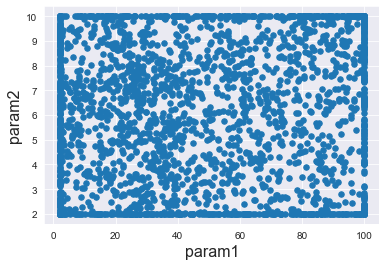

In [46]:
#positions visités par CSA en 2D: max_depth et n_estimators
plt.scatter(ds[0], ds[1],s=30)
plt.xlabel('param1', fontsize=16)
plt.ylabel('param2', fontsize=16)
plt.show()

## Regression logistique

#### Sans CSA

In [47]:
x = df.drop(['Outcome'], axis=1)
y = df['Outcome'].astype(float)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.20, random_state = 0)

In [48]:
clf = LogisticRegression()
clf.fit(x_train, y_train)
y_pred=clf.predict(x_test)
accuracy_RL_without = accuracy_score(y_test,y_pred)*100
accuracy_RL_without

80.51948051948052

#### Avec CSA pour optimiser les hyperparamètres : c et random_state

In [49]:
#CSA
def fitness(variables_values = [1.0,0]):
    classifier = LogisticRegression(C=variables_values[0],random_state=ceil(variables_values[1]))
    classifier.fit(x_train, y_train)
    y_pred = classifier.predict(x_test)
    accuracy = accuracy_score(y_test,y_pred)*100
    return accuracy
def initial_population(population_size = 5, min_values = [0.1,0], max_values = [1000.0,100], target_function = fitness):
    population = np.zeros((population_size, len(min_values) + 1))
    for i in range(0, population_size):
        for j in range(0, len(min_values)):
            population[i,j] = random.uniform(min_values[j], max_values[j]) 
        population[i,-1] = target_function(population[i, 0:population.shape[1]-1])
    return population
def update_position(population, ap, fL, min_values = [0.1,0], max_values = [1000.0,100], target_function = fitness):
    for i in range(0, population.shape[0]):
        idx  = [i for i in range(0, population.shape[0])]
        idx.remove(i)
        idx  = random.choice(idx)
        rand = int.from_bytes(os.urandom(8), byteorder = 'big') / ((1 << 64) - 1)
        for j in range(0, len(min_values)):
            if (rand >= ap):
                rand_i           = int.from_bytes(os.urandom(8), byteorder = 'big') / ((1 << 64) - 1)
                population[i, j] = np.clip(population[i, j] + rand_i*fL*( population[idx, j] - population[i, j]), min_values[j], max_values[j])
            else:
                population[i,j] = random.uniform(min_values[j], max_values[j]) 
        population[i,-1] = target_function(population[i, 0:population.shape[1]-1])
    return population
def crow_search_algorithm(population_size = 30, ap = 0.7, fL =5, min_values = [0.1,0], max_values = [1000.0,100], iterations = 20, target_function = fitness):
    rem=[]
    count      = 0
    population = initial_population(population_size, min_values, max_values, target_function)
    best_ind   = np.copy(population[population[:,-1].argsort()][ 0,:])
    while (count <= iterations):  
        population = update_position(population, ap, fL, min_values, max_values, target_function)
        for i in range(0,population_size):
            value      = np.copy(population[i,:])
            rem.append(value)
            if(best_ind[-1] < value[-1]):
                best_ind = value
        count = count + 1 
    best_ind[1]=int(ceil(best_ind[1]))
    return best_ind,rem

In [50]:
resultat_RL=crow_search_algorithm()
resultat_RL#positions visités par CSA

(array([126.99956078,  81.        ,  85.06493506]),
 [array([273.43817517,  25.23463172,  80.51948052]),
  array([944.45533685,  12.86379171,  80.51948052]),
  array([  0.1       , 100.        ,  79.87012987]),
  array([ 0.1       ,  0.        , 79.87012987]),
  array([149.70903511,   8.53302142,  80.51948052]),
  array([176.49104678,  46.9959475 ,  81.81818182]),
  array([ 0.1       , 33.79221799, 79.87012987]),
  array([117.83486654,  12.40264472,  80.51948052]),
  array([742.51424816,  50.22233266,  80.51948052]),
  array([635.10664313,  22.03638288,  80.51948052]),
  array([218.57332446,  72.12217527,  77.27272727]),
  array([  0.1       , 100.        ,  79.87012987]),
  array([815.86405149,  53.54228146,  80.51948052]),
  array([1000.        ,  100.        ,   81.16883117]),
  array([  0.1       , 100.        ,  79.87012987]),
  array([268.56382834,  32.98748709,  79.87012987]),
  array([811.31031592,  85.73087932,  80.51948052]),
  array([1000.        ,   14.06154095,   81.168831

In [51]:
#the best position
resultat_RL[0]

array([126.99956078,  81.        ,  85.06493506])

In [52]:
accuracy_RL_withCSA=resultat_RL[0][2]

In [53]:
#positions visités par CSA en 3D: c, random_state et accuracy
ds=pd.DataFrame(data=resultat_RL[1])
ds=ds.sort_values(by=[0,1])
ds=ds.drop_duplicates()
fig = px.scatter_3d(ds, x = 0,y = 1, z = 2)
fig.show()

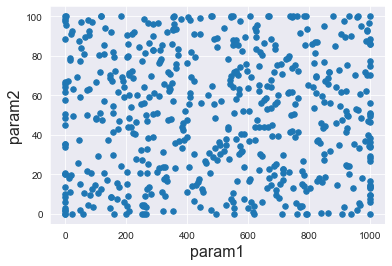

In [54]:
#positions visités par CSA en 2D: c et random_state
plt.scatter(ds[0], ds[1],s=30)
plt.xlabel('param1', fontsize=16)
plt.ylabel('param2', fontsize=16)
plt.show()

## Evaluation 

In [55]:
y1 = [accuracy_KNN_without, accuracy_RF_without, accuracy_RL_without]# les accuracy des modèles sans CSA 
y2 = [accuracy_KNN_withCSA, accuracy_RF_withCSA, accuracy_RL_withCSA]# les accuracy des modèles avec CSA

<AxesSubplot:xlabel='0', ylabel='1'>

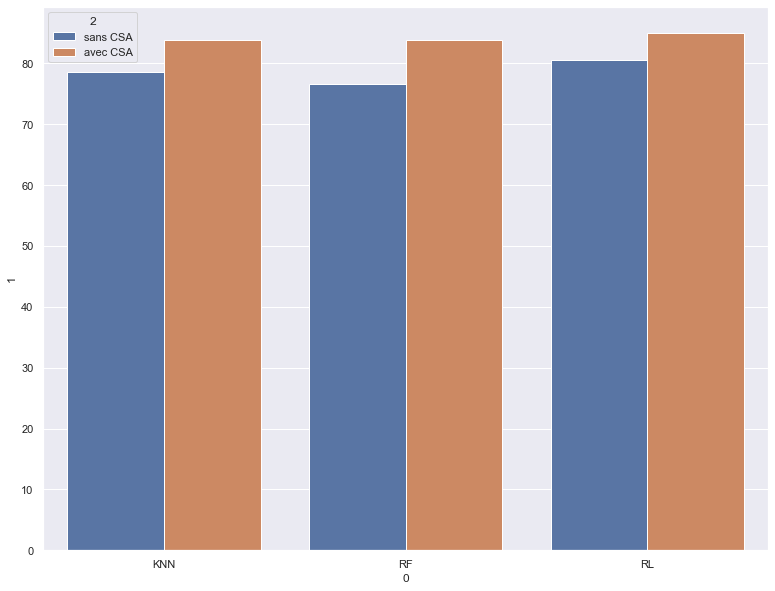

In [56]:
ds=[['KNN',y1[0],'sans CSA'],['KNN',y2[0],'avec CSA'],['RF',y1[1],'sans CSA'],['RF',y2[1],'avec CSA'],['RL',y1[2],'sans CSA'],['RL',y2[2],'avec CSA']]
ds=pd.DataFrame(ds)
sns.set(rc={'figure.figsize':(13,10)})
sns.barplot(data=ds, x=0, y=1, hue=2)

### La précision augmente lors d'optimisation des hyperparamètres des modèles en utilisant Crow Search Algorithm.